# 02 - Intervalos de Confianza

**Pregunta de negocio:** ¿Cuál es nuestro margen de error?

## Objetivos
- Calcular intervalos de confianza (IC) al 95% para métricas clave
- Comparar IC entre tipos de vehículo
- Usar bootstrap para IC de medianas y otras estadísticas

## Teoría
- **Intervalo de confianza**: rango donde esperamos que esté el valor real con X% de confianza
- **IC 95%**: si repitiéramos el experimento 100 veces, ~95 veces el valor real caería dentro del IC
- **IC paramétrico**: asume normalidad. IC = x̄ ± t·(s/√n)
- **Bootstrap**: no asume nada. Remuestrear con reemplazo muchas veces y ver la distribución

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
data_dir = os.path.join(project_root, "data/raw")
rng = np.random.default_rng(42)

In [2]:
# Cargar y agregar por viaje
files = sorted(glob.glob(os.path.join(data_dir, "telemetry/telemetry_*.csv")))
telemetry = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
fleet = pd.read_csv(os.path.join(data_dir, "fleet_profiles.csv"))
telemetry = telemetry.merge(fleet[['vehicle_id', 'vehicle_type']], on='vehicle_id', how='left')

# Agregar por viaje para tener unidades independientes
trip_stats = telemetry.groupby('trip_id').agg(
    speed_mean=('speed_kmh', 'mean'),
    consumption_mean=('fuel_consumption_rate', 'mean'),
    vehicle_type=('vehicle_type', 'first'),
    road_type=('road_type', 'first'),
).reset_index()

surveys = pd.read_csv(os.path.join(data_dir, "surveys/buyer_surveys.csv"))
print(f"Viajes: {len(trip_stats)} | Encuestas: {len(surveys)}")

Viajes: 3234 | Encuestas: 500


## 1. IC paramétrico: consumo por tipo de vehículo

In [3]:
# Calcular IC 95% para el consumo medio de cada tipo
ic_results = []
for vtype in ['electrico', 'hibrido', 'gasolina', 'deportivo']:
    data = trip_stats[trip_stats['vehicle_type'] == vtype]['consumption_mean'].dropna()
    n = len(data)
    mean = data.mean()
    se = data.std() / np.sqrt(n)  # error estándar
    ci = stats.t.interval(0.95, df=n-1, loc=mean, scale=se)
    ic_results.append({
        'Tipo': vtype, 'n': n, 'Media': mean,
        'IC inferior': ci[0], 'IC superior': ci[1],
        'Margen': ci[1] - mean,
    })

ic_df = pd.DataFrame(ic_results)
print("Intervalos de Confianza 95% - Consumo medio por tipo:")
ic_df.round(4)

Intervalos de Confianza 95% - Consumo medio por tipo:


,Tipo,n,Media,IC inferior,IC superior,Margen
0,electrico,996,18.3920,17.8704,18.9136,0.5216
1,hibrido,678,5.8941,5.6909,6.0972,0.2032
2,gasolina,1110,7.8298,7.6954,7.9643,0.1344
3,deportivo,450,12.0139,11.6883,12.3395,0.3256


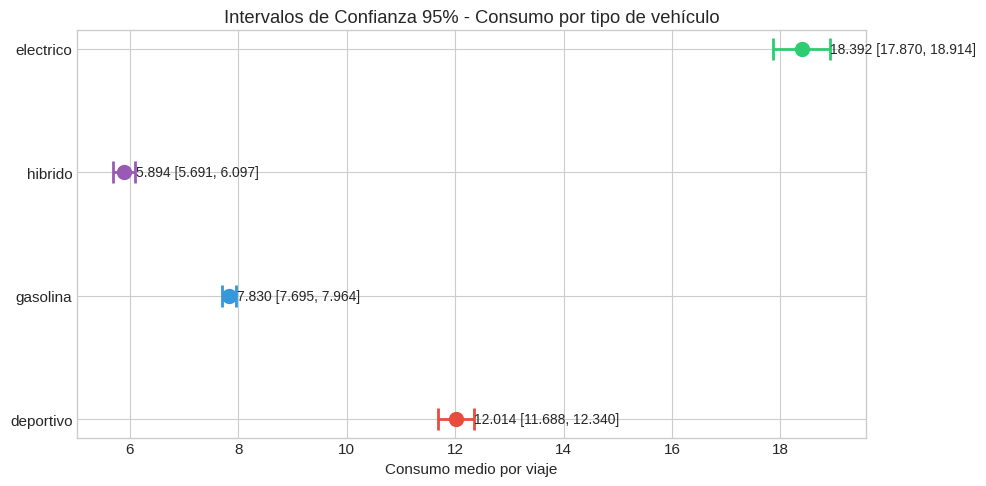

→ Si dos IC NO se solapan, la diferencia probablemente es significativa
→ Si SE solapan, necesitamos un test formal para decidir


In [4]:
# Visualizar IC
vtype_colors = {'electrico': '#2ecc71', 'gasolina': '#3498db', 'hibrido': '#9b59b6', 'deportivo': '#e74c3c'}

fig, ax = plt.subplots(figsize=(10, 5))
for i, row in ic_df.iterrows():
    color = vtype_colors[row['Tipo']]
    ax.errorbar(row['Media'], i, xerr=row['Margen'], fmt='o', color=color,
                capsize=8, capthick=2, markersize=10, linewidth=2)
    ax.text(row['IC superior'] + 0.01, i, 
            f"{row['Media']:.3f} [{row['IC inferior']:.3f}, {row['IC superior']:.3f}]",
            va='center', fontsize=10)

ax.set_yticks(range(len(ic_df)))
ax.set_yticklabels(ic_df['Tipo'])
ax.set_xlabel('Consumo medio por viaje')
ax.set_title('Intervalos de Confianza 95% - Consumo por tipo de vehículo')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("→ Si dos IC NO se solapan, la diferencia probablemente es significativa")
print("→ Si SE solapan, necesitamos un test formal para decidir")

## 2. Bootstrap: IC para la mediana de satisfacción

La mediana no tiene fórmula paramétrica simple. Usamos bootstrap:
1. Tomar N muestras con reemplazo del mismo tamaño
2. Calcular la mediana de cada muestra
3. Los percentiles 2.5% y 97.5% de esas medianas = IC 95%

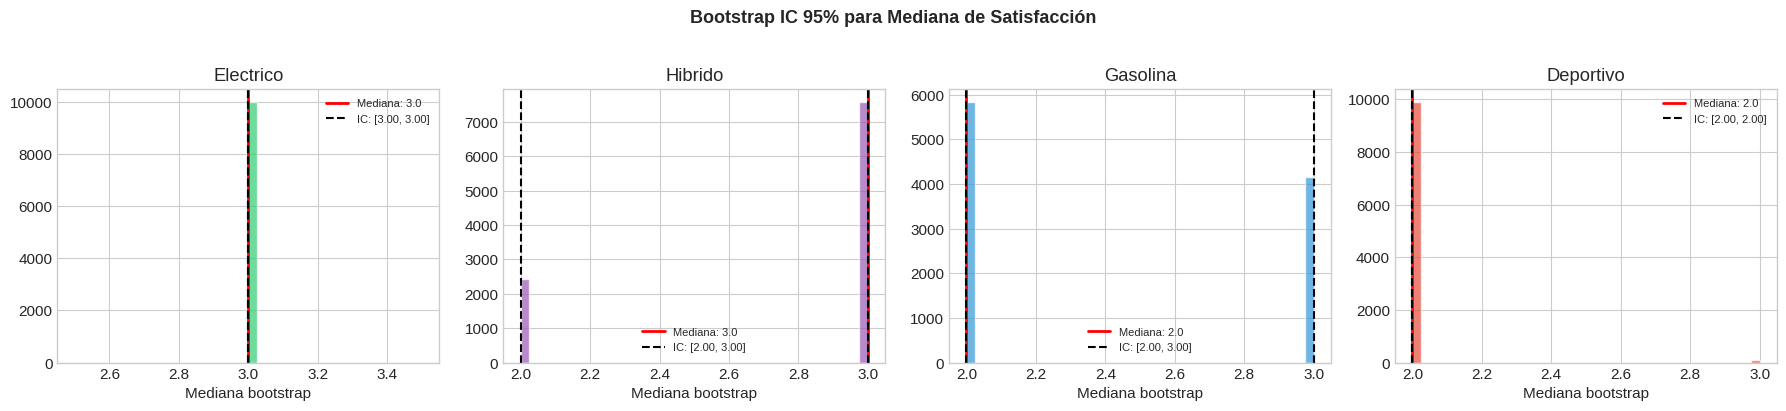

,Tipo,Mediana,IC inf,IC sup
0,electrico,3.0,3.0,3.0
1,hibrido,3.0,2.0,3.0
2,gasolina,2.0,2.0,3.0
3,deportivo,2.0,2.0,2.0


In [5]:
def bootstrap_ci(data, stat_func=np.mean, n_bootstrap=10000, ci=0.95, seed=42):
    """Calcula IC por bootstrap."""
    rng = np.random.default_rng(seed)
    boot_stats = []
    for _ in range(n_bootstrap):
        sample = rng.choice(data, size=len(data), replace=True)
        boot_stats.append(stat_func(sample))
    boot_stats = np.array(boot_stats)
    alpha = (1 - ci) / 2
    return np.percentile(boot_stats, [alpha * 100, (1 - alpha) * 100]), boot_stats

# Bootstrap para mediana de satisfacción por tipo de vehículo
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

boot_results = []
for ax, vtype in zip(axes, ['electrico', 'hibrido', 'gasolina', 'deportivo']):
    sat_data = surveys[surveys['vehicle_type_purchased'] == vtype]['satisfaction_score'].values
    ci_bounds, boot_medians = bootstrap_ci(sat_data, stat_func=np.median)
    
    ax.hist(boot_medians, bins=40, color=vtype_colors[vtype], edgecolor='white', alpha=0.7)
    ax.axvline(np.median(sat_data), color='red', linewidth=2, label=f'Mediana: {np.median(sat_data):.1f}')
    ax.axvline(ci_bounds[0], color='black', linestyle='--', label=f'IC: [{ci_bounds[0]:.2f}, {ci_bounds[1]:.2f}]')
    ax.axvline(ci_bounds[1], color='black', linestyle='--')
    ax.set_title(f'{vtype.capitalize()}')
    ax.legend(fontsize=8)
    ax.set_xlabel('Mediana bootstrap')
    
    boot_results.append({'Tipo': vtype, 'Mediana': np.median(sat_data),
                         'IC inf': ci_bounds[0], 'IC sup': ci_bounds[1]})

plt.suptitle('Bootstrap IC 95% para Mediana de Satisfacción', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

pd.DataFrame(boot_results).round(2)

## 3. Efecto del tamaño de muestra en el IC

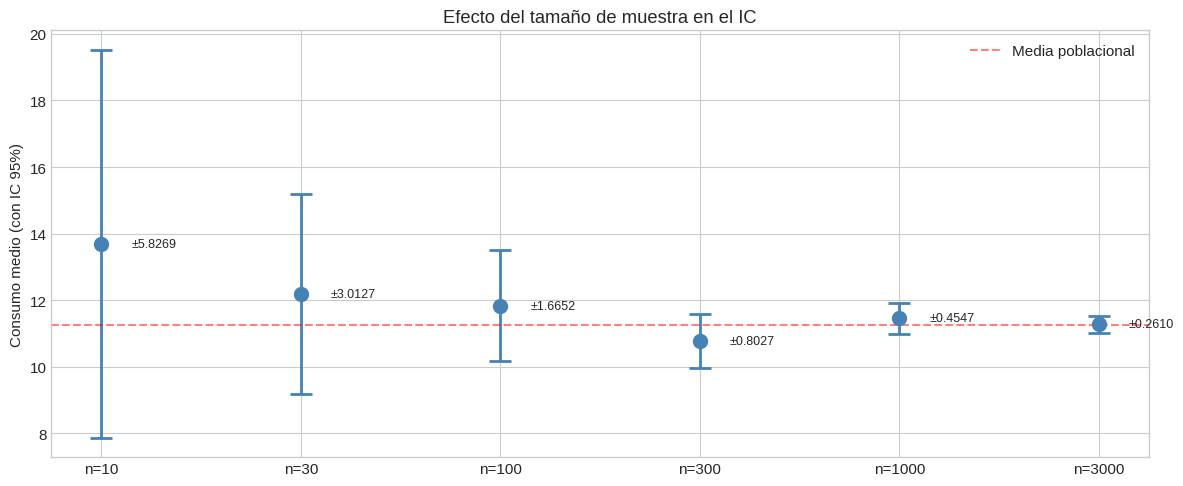

→ Con n=10 el IC es muy ancho (incertidumbre alta)
→ Con n=1000+ el IC es muy estrecho (estimación precisa)
→ El ancho del IC se reduce con √n (duplicar precisión requiere 4x datos)


In [6]:
# Demostrar: más datos = IC más estrecho
consumption = trip_stats['consumption_mean'].dropna().values
sample_sizes = [10, 30, 100, 300, 1000, 3000]

fig, ax = plt.subplots(figsize=(12, 5))
widths = []

for i, n in enumerate(sample_sizes):
    sample = rng.choice(consumption, size=min(n, len(consumption)), replace=False)
    mean = sample.mean()
    se = sample.std() / np.sqrt(len(sample))
    ci = stats.t.interval(0.95, df=len(sample)-1, loc=mean, scale=se)
    width = ci[1] - ci[0]
    widths.append(width)
    
    ax.errorbar(i, mean, yerr=(mean - ci[0]), fmt='o', capsize=8, capthick=2,
                markersize=10, color='steelblue', linewidth=2)
    ax.text(i + 0.15, mean, f'±{width/2:.4f}', va='center', fontsize=9)

ax.set_xticks(range(len(sample_sizes)))
ax.set_xticklabels([f'n={n}' for n in sample_sizes])
ax.set_ylabel('Consumo medio (con IC 95%)')
ax.set_title('Efecto del tamaño de muestra en el IC')
ax.axhline(consumption.mean(), color='red', linestyle='--', alpha=0.5, label='Media poblacional')
ax.legend()
plt.tight_layout()
plt.show()

print("→ Con n=10 el IC es muy ancho (incertidumbre alta)")
print("→ Con n=1000+ el IC es muy estrecho (estimación precisa)")
print("→ El ancho del IC se reduce con √n (duplicar precisión requiere 4x datos)")

## 4. IC para proporciones: tasa de recomendación

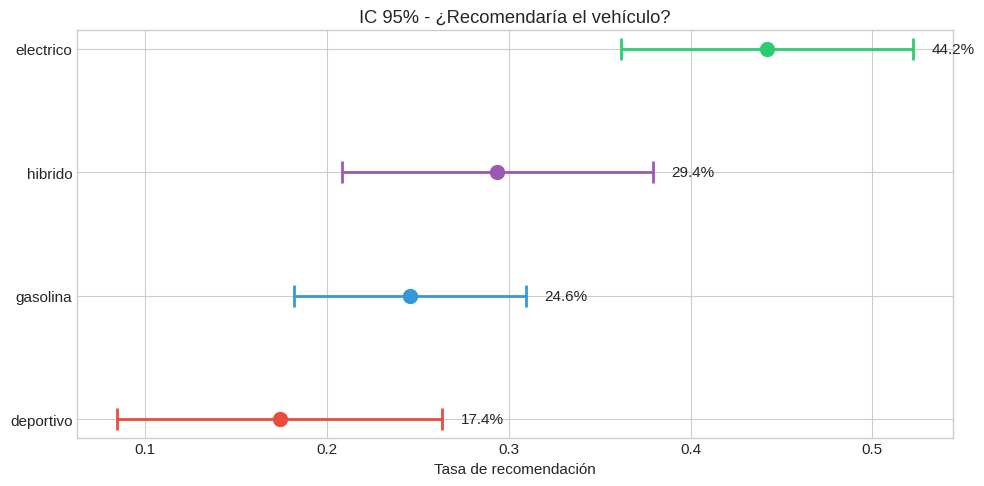

,Tipo,Proporción,IC inf,IC sup,n
0,electrico,0.442,0.362,0.522,147
1,hibrido,0.294,0.208,0.379,109
2,gasolina,0.246,0.182,0.309,175
3,deportivo,0.174,0.084,0.263,69


In [7]:
# IC para proporción: p ± z·√(p(1-p)/n)
fig, ax = plt.subplots(figsize=(10, 5))

prop_results = []
for vtype in ['electrico', 'hibrido', 'gasolina', 'deportivo']:
    subset = surveys[surveys['vehicle_type_purchased'] == vtype]
    n = len(subset)
    p = subset['would_recommend'].mean()
    se = np.sqrt(p * (1 - p) / n)
    ci = (p - 1.96 * se, p + 1.96 * se)
    prop_results.append({'Tipo': vtype, 'Proporción': p, 'IC inf': ci[0], 'IC sup': ci[1], 'n': n})

pr = pd.DataFrame(prop_results)
for i, row in pr.iterrows():
    color = vtype_colors[row['Tipo']]
    ax.errorbar(row['Proporción'], i, xerr=row['Proporción'] - row['IC inf'],
                fmt='o', color=color, capsize=8, capthick=2, markersize=10, linewidth=2)
    ax.text(row['IC sup'] + 0.01, i, f"{row['Proporción']:.1%}", va='center')

ax.set_yticks(range(len(pr)))
ax.set_yticklabels(pr['Tipo'])
ax.set_xlabel('Tasa de recomendación')
ax.set_title('IC 95% - ¿Recomendaría el vehículo?')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

pr.round(3)

## Resumen

### Lo que aprendimos:
1. **IC paramétrico**: rápido, asume normalidad. Usa x̄ ± t·(s/√n)
2. **Bootstrap**: no asume nada, funciona para cualquier estadística (mediana, percentiles)
3. Más datos → IC más estrecho (relación √n)
4. Si dos IC no se solapan → diferencia probablemente significativa

### Respuesta:
> **¿Cuál es nuestro margen de error?**
>
> Con nuestra cantidad de datos, los IC son estrechos. Podemos estimar el consumo
> medio por tipo con alta precisión. La mediana de satisfacción tiene más incertidumbre
> porque es una escala discreta (1-5). Las tasas de recomendación tienen IC que
> dependen del tamaño de cada segmento.

### Siguiente:
→ `03_hypothesis_testing_telemetry.ipynb`: Tests de hipótesis en telemetría